In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================================
# ⚡ PM2.5 Classification (5 Classes) using Parallel Linear SVM (SGDClassifier) + Borderline-SMOTE (Train only)
# =========================================================
# === Block 1: Import Libraries ===
!pip install tqdm -q

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import os, warnings

warnings.filterwarnings('ignore')


In [3]:
# === Block 2: Optimize Resource Usage ===
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())
print(f"💻 Using CPU Threads: {os.cpu_count()}")
!free -h && nproc

💻 Using CPU Threads: 2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       7.9Gi       1.0Mi       3.5Gi        11Gi
Swap:             0B          0B          0B
2


In [4]:
# === Block 3: Load Dataset ===
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")

Train shape: (329623, 13), Test shape: (82406, 13)


In [5]:
# === Block 4: Separate Features and Target ===
TARGET = 'PM2.5_level'
X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]
X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET]

In [6]:
# === Block 5: Apply Borderline-SMOTE before 10-Fold ===
from collections import Counter
from imblearn.over_sampling import BorderlineSMOTE

# ตรวจสอบ class distribution ก่อน oversampling
print("Before SMOTE:")
print(y_train.value_counts())

# นับจำนวนตัวอย่างในแต่ละคลาส
class_counts = Counter(y_train)

# หา class ที่มีจำนวนมากที่สุด (majority)
majority_count = max(class_counts.values())

# คำนวณเป้าหมาย = 50% ของจำนวนคลาสที่มากที่สุด
target_size = int(majority_count * 0.5)

# สร้าง sampling strategy สำหรับเฉพาะ class 2 และ 3 (ถ้าจำนวนน้อยกว่าเป้าหมาย)
sampling_strategy = {
    cls: target_size for cls in [2, 3] if class_counts[cls] < target_size
}

print("\nDynamic sampling strategy:")
print(sampling_strategy)

# ใช้ Borderline-SMOTE ตาม strategy ที่คำนวณได้
bsmote = BorderlineSMOTE(
    kind='borderline-1',
    random_state=42,
    sampling_strategy=sampling_strategy
)
X_resampled, y_resampled = bsmote.fit_resample(X_train, y_train)

# ตรวจสอบผลลัพธ์หลัง oversampling
print("\nAfter Borderline-SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
PM2.5_level
5    128801
4     73062
1     64314
2     33504
3     29942
Name: count, dtype: int64

Dynamic sampling strategy:
{2: 64400, 3: 64400}

After Borderline-SMOTE:
PM2.5_level
5    128801
4     73062
3     64400
2     64400
1     64314
Name: count, dtype: int64


In [7]:
# === Block 6: 10-Fold Cross Validation ===
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []
model = SGDClassifier(loss='hinge', random_state=42, max_iter=5000, n_jobs=-1)

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_resampled, y_resampled), total=10), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    y_val_score = model.decision_function(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')
    y_val_bin = label_binarize(y_val, classes=sorted(y_resampled.unique()))
    auc_val = roc_auc_score(y_val_bin, y_val_score, average='macro', multi_class='ovr')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc_val)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={auc_val:.3f}")

 10%|█         | 1/10 [00:02<00:23,  2.59s/it]

Fold 1: Accuracy=0.544, Precision=0.493, Recall=0.544, F1=0.441, AUC=0.802


 20%|██        | 2/10 [00:05<00:20,  2.53s/it]

Fold 2: Accuracy=0.579, Precision=0.474, Recall=0.579, F1=0.476, AUC=0.799


 30%|███       | 3/10 [00:09<00:22,  3.22s/it]

...

Fold 8: Accuracy=0.554, Precision=0.486, Recall=0.554, F1=0.470, AUC=0.791


 90%|█████████ | 9/10 [00:25<00:02,  2.89s/it]

Fold 9: Accuracy=0.566, Precision=0.558, Recall=0.566, F1=0.481, AUC=0.797


100%|██████████| 10/10 [00:28<00:00,  2.81s/it]

Fold 10: Accuracy=0.566, Precision=0.449, Recall=0.566, F1=0.487, AUC=0.803


In [8]:
# === Block 7: Display CV Summary ===
cv_results = pd.DataFrame({
    'Fold': list(range(1, len(acc_scores)+1)),
    'Accuracy': acc_scores,
    'Precision': prec_scores,
    'Recall': rec_scores,
    'F1': f1_scores,
    'AUC_ROC': auc_scores
})

print("\n=== 10-Fold Cross Validation Results ===")
print(cv_results)

# === ค่าเฉลี่ย (Mean) ===
print("\n📊 Cross-validation (10 folds) Avg Metrics:")
print(f"Accuracy : {np.mean(acc_scores):.3f}")
print(f"Precision: {np.mean(prec_scores):.3f}")
print(f"Recall   : {np.mean(rec_scores):.3f}")
print(f"F1-score : {np.mean(f1_scores):.3f}")
print(f"AUC-ROC  : {np.mean(auc_scores):.3f}")

# === ค่า Mean ± SD (เพิ่มส่วนนี้) ===
acc_mean, acc_sd = np.mean(acc_scores), np.std(acc_scores)
prec_mean, prec_sd = np.mean(prec_scores), np.std(prec_scores)
rec_mean, rec_sd = np.mean(rec_scores), np.std(rec_scores)
f1_mean, f1_sd = np.mean(f1_scores), np.std(f1_scores)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

print("\n📈 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")




=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.544179   0.493276  0.544179  0.441023  0.802070
1     2  0.578561   0.473911  0.578561  0.476321  0.798664
2     3  0.534559   0.361905  0.534559  0.430298  0.790385
3     4  0.536685   0.472818  0.536685  0.436681  0.795406
4     5  0.556585   0.565991  0.556585  0.473847  0.791492
5     6  0.554104   0.493746  0.554104  0.484868  0.795706
6     7  0.559421   0.508960  0.559421  0.486267  0.798232
7     8  0.554169   0.486419  0.554169  0.470072  0.790916
8     9  0.565916   0.558170  0.565916  0.480924  0.796576
9    10  0.566271   0.449183  0.566271  0.486790  0.802650

📊 Cross-validation (10 folds) Avg Metrics:
Accuracy : 0.555
Precision: 0.486
Recall   : 0.555
F1-score : 0.467
AUC-ROC  : 0.796

📈 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.555 ± 0.013
Precision: 0.486 ± 0.054
Recall   : 0.555 ± 0.013
F1-score : 0.467 ± 0.021
AUC-ROC  : 0.796 ± 0.004


In [9]:
# === (Optional) Save Mean ± SD summary ===
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/MeanSD/'
summary_path = base_path + '2-3KNN_BDL_mean_sd.csv'

# ✅ สร้างโฟลเดอร์อัตโนมัติ
os.makedirs(base_path, exist_ok=True)
cv_summary.to_csv(summary_path, index=False)

print(f"\n💾 Mean + SD summary saved to {summary_path}")


💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/MeanSD/2-3KNN_BDL_mean_sd.csv


In [10]:
# === Block 8: Evaluate on Test Set ===
model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)
y_test_score = model.decision_function(X_test)

classes = sorted(y_resampled.unique())
y_test_bin = label_binarize(y_test, classes=classes)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_auc = roc_auc_score(y_test_bin, y_test_score, average='macro', multi_class='ovr')

print("\n📈 Test Set Metrics:")
print(f"Accuracy: {acc_test:.3f}, Precision: {prec_test:.3f}, Recall: {rec_test:.3f}, F1: {f1_test:.3f}, AUC: {test_auc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))



📈 Test Set Metrics:
Accuracy: 0.618, Precision: 0.447, Recall: 0.618, F1: 0.515, AUC: 0.807

Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.90      0.78     16078
           2       0.00      0.00      0.00      8376
           3       0.27      0.67      0.39      7486
           4       0.00      0.00      0.00     18265
           5       0.74      0.98      0.84     32201

    accuracy                           0.62     82406
   macro avg       0.34      0.51      0.40     82406
weighted avg       0.45      0.62      0.52     82406

Confusion Matrix:
 [[14437     0  1517     0   124]
 [ 4422     0  3716     0   238]
 [ 1463     0  5050     0   973]
 [  552     0  7750     0  9963]
 [   43     0   679     0 31479]]


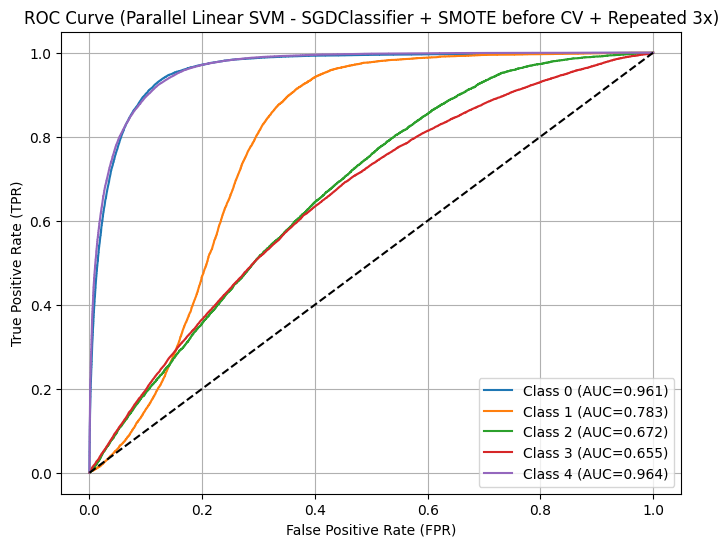

In [11]:
# === Block 9: ROC Curve ===
n_classes = len(classes)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (Parallel Linear SVM - SGDClassifier + SMOTE before CV + Repeated 3x)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# === Block 10: Save Model, AUC CSV, and ROC Data ===
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/'
joblib.dump(model, base_path + '2-3svm_sgd_borderline.pkl')
print(f"💾 Model saved as {base_path}2-3svm_sgd_borderline.pkl")

output_auc = pd.DataFrame({
    'Fold': list(range(1, len(acc_scores)+1)) + ['Test Set'],
    'AUC_ROC': auc_scores + [test_auc]
})
output_auc.to_csv(base_path + '2-3svm_sgd_borderline_scores.csv', index=False)
print(f"💾 AUC results saved as {base_path}2-3svm_sgd_borderline_scores.csv")

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

roc_df = pd.DataFrame({'fpr': all_fpr, 'tpr': mean_tpr})
roc_df.to_csv(base_path + '2-3svm_sgd_borderline_roc_data.csv', index=False)
print(f"💾 ROC data saved as {base_path}2-3svm_sgd_borderline_roc_data.csv")
print(f"Macro AUC = {macro_auc:.4f}")
print(roc_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_sgd_borderline.pkl
💾 AUC results saved as /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_sgd_borderline_scores.csv
💾 ROC data saved as /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_sgd_borderline_roc_data.csv
Macro AUC = 0.8071
        fpr       tpr
0  0.000000  0.003406
1  0.000013  0.003406
2  0.000014  0.003406
3  0.000015  0.003667
4  0.000016  0.003678
